# The 1% Allocation — a quantitative teardown \U0001F52C
### Inverting the optimiser · bootstrapping it · σ²/SE² years of data

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The decisive
section is **§3.4b**, which inverts the optimiser: instead of asking what weight the data
implies, it asks what expected return each *published* weight implies. §1 records the
pre-registered hypothesis this study rejected on the way there.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md), bitcoin aligned to the equity calendar.
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from onepercent import data, strategy as st

px = data.load_prices()
rets = st.align_to_equity_calendar(px, data.EQUITY).pct_change()
base = st.sixty_forty(rets, data.EQUITY, data.BONDS)
btc = rets[data.BTC].dropna()
common = base.index.intersection(btc.index)
base, btc = base.loc[common], btc.loc[common]
print(f"as-of {data.AS_OF} | {len(common):,} common sessions from "
      f"{common[0].date()} ({len(common)/252:.1f} years)")
b = st.stats(base)
print(f"the 60/40 alone: {b['cagr']:.2%} a year, {b['vol']:.1%} vol, "
      f"Sharpe {b['sharpe']:.2f}")

as-of 2026-06-30 | 2,962 common sessions from 2014-09-18 (11.8 years)
the 60/40 alone: 9.31% a year, 10.9% vol, Sharpe 0.85


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | Emphatically, in sample. Over 11.8 years to 2026-06-30, a 60/40 returned 9.31% a year at 10.9% volatility, Sharpe 0.85. The Sharpe-maximising bitcoin sleeve was **16.5%** — not 1%, not 2% — lifting the ratio to 1.18 on a 18.68% return, at the cost of a -31.2% maximum drawdown against the base portfolio's -21.7%. That number is what the historical record says, and the gap between it and every published recommendation is the whole subject of this study. One correction along the way: bitcoin trades 365 days a year and the rest of a portfolio does not, so everything here is aligned to the equity calendar; skipping that step changes bitcoin's annualised volatility by 20% and every ratio built on it. |
| **Tradability** | Mirage | So why does nobody recommend 16%? Because nobody believes the realised mean. Bitcoin returned 51% a year over this sample; inverting the optimiser shows what each published allocation is really assuming. A **1% sleeve is optimal if you expect bitcoin to return -5.0% a year**. A 2% sleeve implies -2.0% — essentially nothing. A 5% sleeve implies +8.0%, about what equities are expected to do. These are not cautious readings of the data; they are the answers you get **after discarding it**, which is a defensible position and an entirely different one from what the accompanying backtests imply. The override is justified by the standard error: at 55% volatility, pinning bitcoin's expected return to ±2 percentage points takes **765 years**, and 12 years leaves a standard error of 16% — so the 51% is not knowledge. Out of sample the walk-forward allocator returned 15.11% against the base portfolio's 10.00%, with its chosen weight swinging from 4.7% to 20.0%. The honest form of a bitcoin recommendation states the expected return it assumes; the weight then follows, and can be argued with. |

> \U0001F4A1 **In plain words.** Unbiased and useless are not the same thing.

## 1 · Hypotheses

Stated as they were **before** the run, including the one that failed — which is where the
study's actual thesis came from.

- **H₁ (in-sample).** A bitcoin sleeve raised the realised Sharpe ratio of a 60/40.
- **H₂ (the optimiser's answer).** It is far larger than any published recommendation.
- **H₃ (interval).** A block bootstrap of the optimiser gives a wide 90% interval.
- **H₄ (power) — ✗ REJECTED.** *Pre-registered as "the sample cannot rank a 1% sleeve against a
  5% one".* It can, decisively: 5% wins in nearly every bootstrap draw. Conditioned on
  bitcoin's realised return the data is not ambiguous, and the small published allocations
  therefore cannot be defended as statistical caution. §3.4b replaces the question with the one
  that survives: *what expected return does each recommendation assume?*
- **H₅ (arithmetic).** The years needed to pin the mean to ±2pp exceed any available history
  and scale with σ² — which is what makes overriding the realised mean the correct instinct.
- **H₆ (control).** On planted data with a *known* optimum, the optimiser is unbiased at long
  samples and has a standard deviation comparable to the answer at realistic ones.

## 2 · Data, and the calendar correction

In [3]:
rows = []
for tk in data.TICKERS:
    if tk not in px.columns:
        continue
    s = px[tk].dropna()
    r = s.pct_change().dropna()
    span_years = (s.index[-1] - s.index[0]).days / 365.25
    rows.append({"ticker": tk, "n": len(s), "from": s.index[0].date(),
                 "obs/year": len(s) / span_years,
                 "vol (252)": r.std(ddof=1) * np.sqrt(252),
                 "vol (365)": r.std(ddof=1) * np.sqrt(365)})
d = pd.DataFrame(rows).set_index("ticker")
print(d.round(3).to_string())
print()
print("Every series has ~252 observations a year because bitcoin has been reindexed onto")
print("the equity calendar. The two volatility columns show what the alternative costs.")

            n        from  obs/year  vol (252)  vol (365)
ticker                                                   
BTC-USD  4305  2014-09-17  365.3350     0.5530     0.6660
SPY      8411  1993-01-29  251.7100     0.1860     0.2240
AGG      5724  2003-09-29  251.5870     0.0520     0.0620
TLT      6018  2002-07-30  251.6110     0.1430     0.1720
GLD      5436  2004-11-18  251.5200     0.1820     0.2190
BIL      4802  2007-05-30  251.6040     0.0050     0.0060

Every series has ~252 observations a year because bitcoin has been reindexed onto
the equity calendar. The two volatility columns show what the alternative costs.


## 3 · The teardown

### 3.1 The full sweep, several objectives

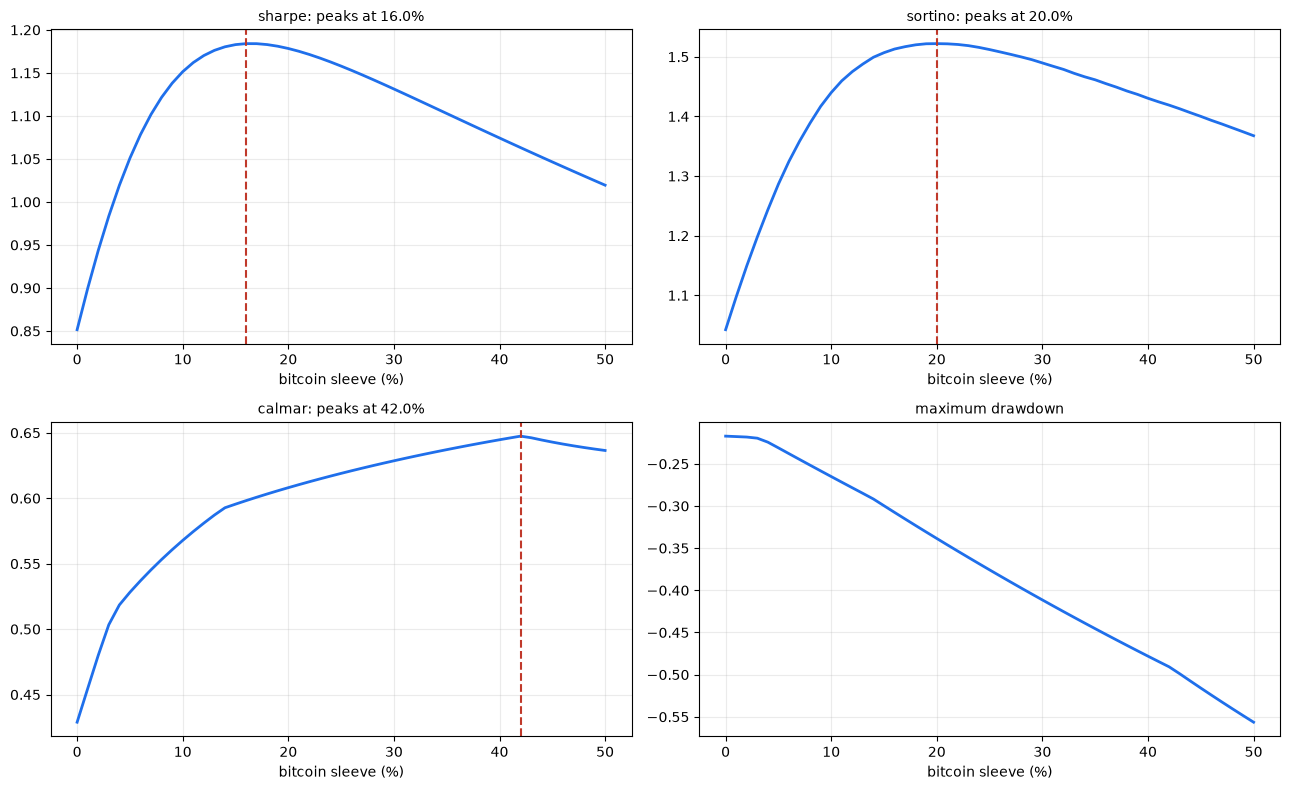

{'sharpe': '16.00%', 'sortino': '20.00%', 'calmar': '42.00%'}


In [4]:
rows = []
for w in np.linspace(0, 0.5, 51):
    s = st.stats(st.sleeve(base, btc, w))
    if s:
        rows.append({"weight": w, **s})
d = pd.DataFrame(rows).set_index("weight")
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), ["sharpe", "sortino", "calmar", "max_drawdown"]):
    ax.plot(d.index * 100, d[col], lw=2, color="#1f6feb")
    if col != "max_drawdown":
        ax.axvline(d[col].idxmax() * 100, color="#c0392b", ls="--", lw=1.5)
        ax.set_title(f"{col}: peaks at {d[col].idxmax():.1%}", fontsize=10)
    else:
        ax.set_title("maximum drawdown", fontsize=10)
    ax.set_xlabel("bitcoin sleeve (%)")
plt.tight_layout(); plt.show()
print({c: f"{d[c].idxmax():.2%}" for c in ("sharpe", "sortino", "calmar")})

> \U0001F4A1 **In plain words.** Three reasonable objectives, three different "optimal"
> allocations. Before any statistical uncertainty is considered at all.

### 3.2 The plateau, at several tolerances

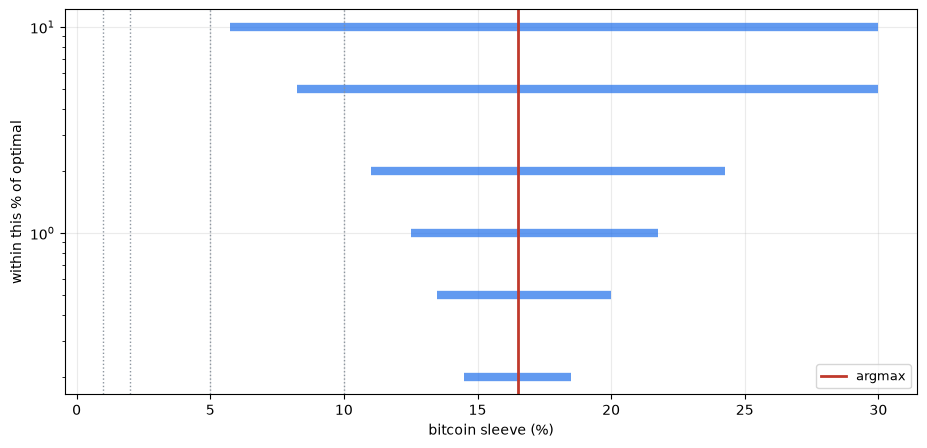

           best_weight  plateau_lo  plateau_hi  plateau_width
tolerance                                                    
0.0020          0.1650      0.1450      0.1850         0.0400
0.0050          0.1650      0.1350      0.2000         0.0650
0.0100          0.1650      0.1250      0.2175         0.0925
0.0200          0.1650      0.1100      0.2425         0.1325
0.0500          0.1650      0.0825      0.3000         0.2175
0.1000          0.1650      0.0575      0.3000         0.2425


In [5]:
curve = st.objective_curve(base, btc, 0.30, n=121)
rows = [{"tolerance": t, **st.flatness(curve, t)}
        for t in (0.002, 0.005, 0.01, 0.02, 0.05, 0.10)]
d = pd.DataFrame(rows).set_index("tolerance")
fig, ax = plt.subplots(figsize=(11, 5))
for t, row in d.iterrows():
    ax.plot([row["plateau_lo"] * 100, row["plateau_hi"] * 100], [t * 100, t * 100],
            lw=6, alpha=0.7, color="#1f6feb", solid_capstyle="butt")
ax.axvline(d["best_weight"].iloc[0] * 100, color="#c0392b", lw=2, label="argmax")
for w in (1, 2, 5, 10):
    ax.axvline(w, color="#8b949e", ls=":", lw=1)
ax.set_yscale("log"); ax.set_xlabel("bitcoin sleeve (%)")
ax.set_ylabel("within this % of optimal"); ax.legend(fontsize=9)
plt.show()
print(d[["best_weight", "plateau_lo", "plateau_hi", "plateau_width"]].round(4).to_string())

### 3.3 Bootstrapping the optimiser

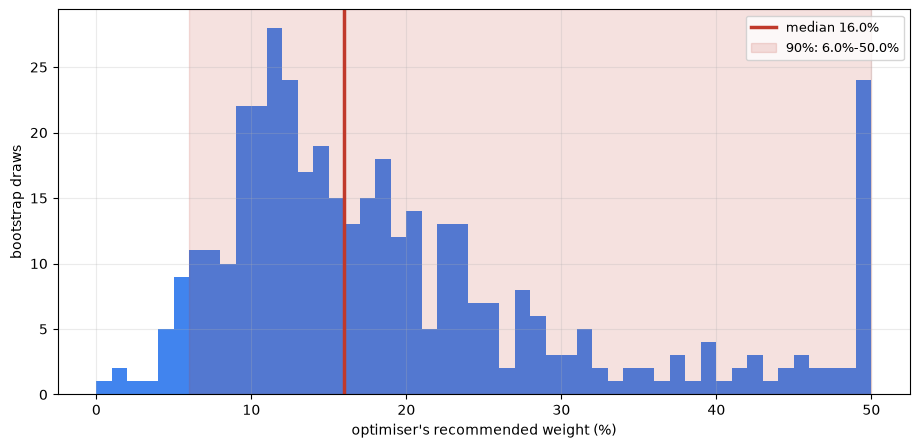

{'mean': 0.1957, 'median': 0.16, 'sd': 0.1222, 'p05': 0.06, 'p95': 0.5, 'share_at_zero': 0.0025, 'share_at_cap': 0.0575}


In [6]:
boot = st.weight_standard_error(base, btc, 0.50, n_boot=400)
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(boot["draws"] * 100, bins=50, color="#1f6feb", alpha=0.85)
ax.axvline(boot["median"] * 100, color="#c0392b", lw=2.5,
           label=f"median {boot['median']:.1%}")
ax.axvspan(boot["p05"] * 100, boot["p95"] * 100, alpha=0.15, color="#c0392b",
           label=f"90%: {boot['p05']:.1%}-{boot['p95']:.1%}")
ax.set_xlabel("optimiser's recommended weight (%)"); ax.set_ylabel("bootstrap draws")
ax.legend(fontsize=9)
plt.show()
print({k: round(v, 4) for k, v in boot.items() if k != "draws"})

> \U0001F4A1 **In plain words.** Resampled in blocks, so volatility clustering survives. An
> i.i.d. bootstrap would give a narrower interval and a falsely confident recommendation.

### 3.4b The inversion — the study's actual finding

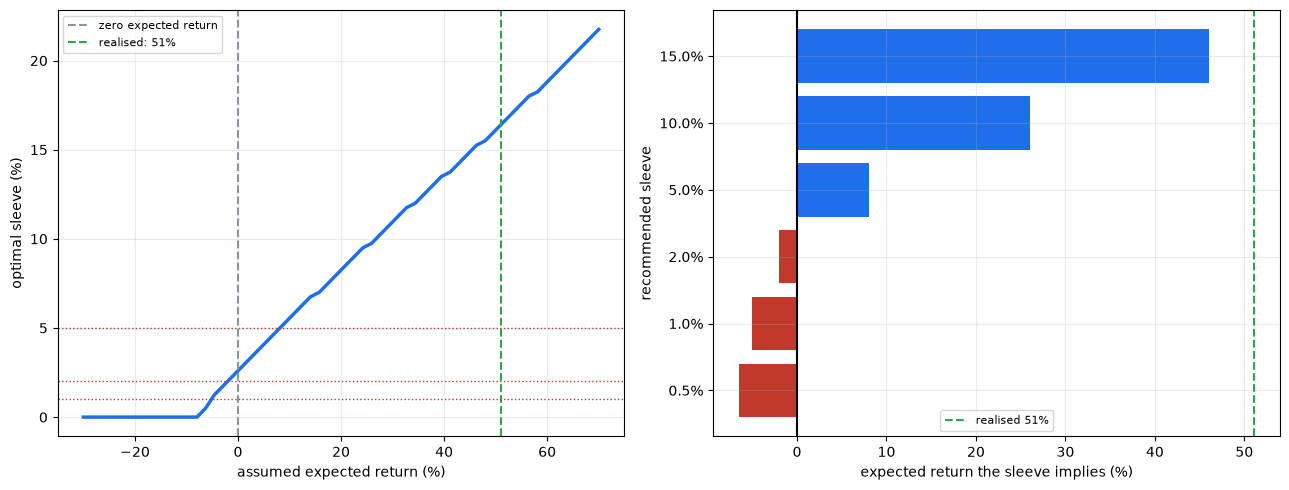

        implied_mean  nearest_grid_weight
weight                                   
0.0050       -0.0650               0.0075
0.0100       -0.0500               0.0100
0.0200       -0.0200               0.0200
0.0500        0.0800               0.0500
0.1000        0.2600               0.1000
0.1500        0.4600               0.1500


In [7]:
imp = st.implied_mean_for_weight(base, btc, (0.005, 0.01, 0.02, 0.05, 0.10, 0.15))
curve = st.weight_vs_assumed_mean(base, btc, np.linspace(-0.30, 0.70, 60))
realised = np.expm1(np.log1p(btc).sum() * 252 / len(btc))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(curve.index * 100, curve["optimal_weight"] * 100, lw=2.5, color="#1f6feb")
axes[0].axvline(0, color="#8b949e", ls="--", lw=1.5, label="zero expected return")
axes[0].axvline(realised * 100, color="#2ea44f", ls="--", lw=1.5,
                label=f"realised: {realised:.0%}")
for w in (0.01, 0.02, 0.05):
    axes[0].axhline(w * 100, color="#c0392b", ls=":", lw=1)
axes[0].set_xlabel("assumed expected return (%)")
axes[0].set_ylabel("optimal sleeve (%)"); axes[0].legend(fontsize=8)
axes[1].barh([f"{w:.1%}" for w in imp.index], imp["implied_mean"] * 100,
             color=["#c0392b" if m < 0 else "#1f6feb" for m in imp["implied_mean"]])
axes[1].axvline(0, color="k", lw=1.5)
axes[1].axvline(realised * 100, color="#2ea44f", ls="--", lw=1.5,
                label=f"realised {realised:.0%}")
axes[1].set_xlabel("expected return the sleeve implies (%)")
axes[1].set_ylabel("recommended sleeve"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(imp.round(4).to_string())

> \U0001F4A1 **In plain words.** The right-hand bars are the punchline. A 2% allocation is the
> optimiser's answer *if you assume bitcoin earns nothing*; a 1% allocation assumes it loses
> money. Those are priors, not inferences, and §3.5 shows why holding such a prior is
> reasonable — the realised return simply is not evidence about the expected one at this
> volatility. What is not reasonable is illustrating the recommendation with the chart it
> contradicts.

### 3.4c Sampling uncertainty cannot get you there

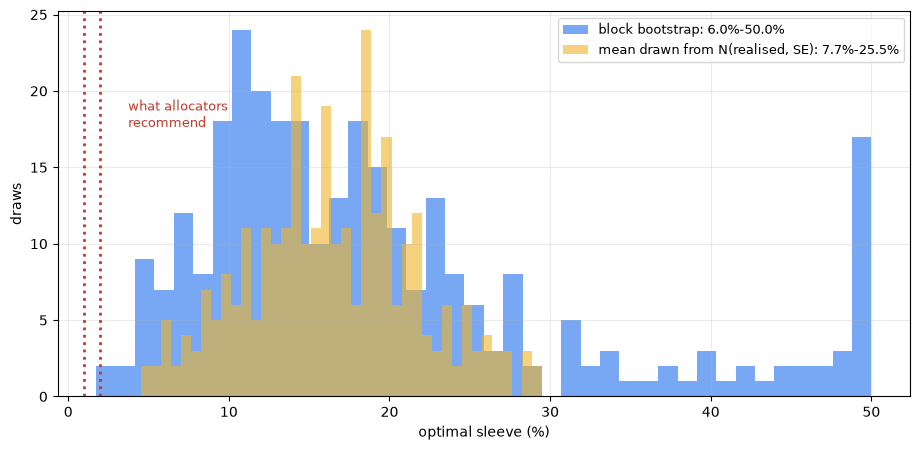

standard error on bitcoin's mean return: 19.3% a year
Neither distribution reaches down to 1-2%. No treatment of SAMPLING uncertainty
does, because every draw still carries a mean within a couple of standard errors
of 51%. Only a different prior gets you there.


In [8]:
boot = st.weight_standard_error(base, btc, 0.50, n_boot=300)
mu = st.weight_with_mean_uncertainty(base, btc, 0.50, n_draws=300)
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(boot["draws"] * 100, bins=40, alpha=0.6, color="#1f6feb",
        label=f"block bootstrap: {boot['p05']:.1%}-{boot['p95']:.1%}")
ax.hist(mu["draws"] * 100, bins=40, alpha=0.6, color="#f0b429",
        label=f"mean drawn from N(realised, SE): {mu['p05']:.1%}-{mu['p95']:.1%}")
for w, col in ((1, "#c0392b"), (2, "#c0392b")):
    ax.axvline(w, color=col, lw=2, ls=":")
ax.annotate("what allocators\nrecommend", (2, ax.get_ylim()[1] * 0.7), fontsize=9,
            color="#c0392b", xytext=(20, 0), textcoords="offset points")
ax.set_xlabel("optimal sleeve (%)"); ax.set_ylabel("draws"); ax.legend(fontsize=9)
plt.show()
print(f"standard error on bitcoin's mean return: {mu['mean_se']:.1%} a year")
print("Neither distribution reaches down to 1-2%. No treatment of SAMPLING uncertainty")
print("does, because every draw still carries a mean within a couple of standard errors")
print(f"of {mu['realised_mean']:.0%}. Only a different prior gets you there.")

### 3.4 Can the sample rank two allocations?

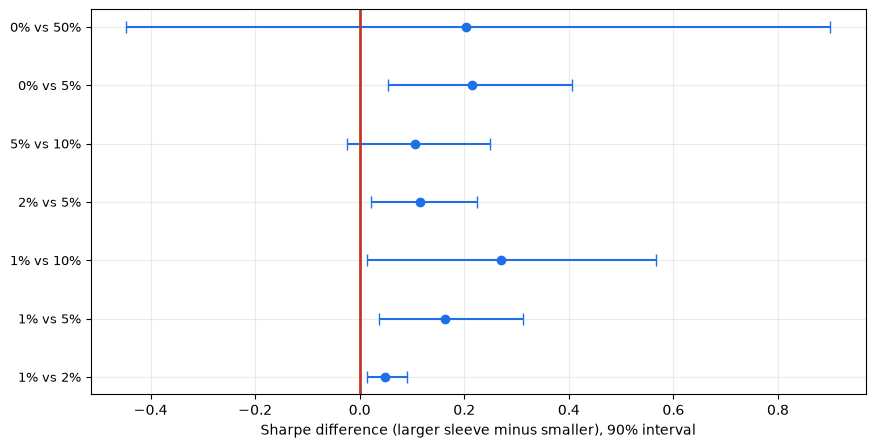

           mean_diff  sd_diff  share_b_wins  distinguishable
pair                                                        
1% vs 2%      0.0478   0.0230        1.0000             True
1% vs 5%      0.1634   0.0852        0.9920             True
1% vs 10%     0.2697   0.1653        0.9560             True
2% vs 5%      0.1156   0.0624        0.9920             True
5% vs 10%     0.1063   0.0824        0.9120            False
0% vs 5%      0.2155   0.1088        0.9920             True
0% vs 50%     0.2040   0.4089        0.6560            False


In [9]:
rows = []
for wa, wb in ((0.01, 0.02), (0.01, 0.05), (0.01, 0.10), (0.02, 0.05), (0.05, 0.10),
               (0.0, 0.05), (0.0, 0.50)):
    p = st.power_to_distinguish(base, btc, wa, wb, n_boot=250)
    rows.append({"pair": f"{wa:.0%} vs {wb:.0%}", **p})
d = pd.DataFrame(rows).set_index("pair")
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(d))
ax.errorbar(d["mean_diff"], y, xerr=[d["mean_diff"] - d["p05"], d["p95"] - d["mean_diff"]],
            fmt="o", capsize=4, color="#1f6feb")
ax.axvline(0, color="#c0392b", lw=2)
ax.set_yticks(y); ax.set_yticklabels(d.index, fontsize=9)
ax.set_xlabel("Sharpe difference (larger sleeve minus smaller), 90% interval")
plt.show()
print(d[["mean_diff", "sd_diff", "share_b_wins", "distinguishable"]].round(4).to_string())

### 3.5 Merton's arithmetic

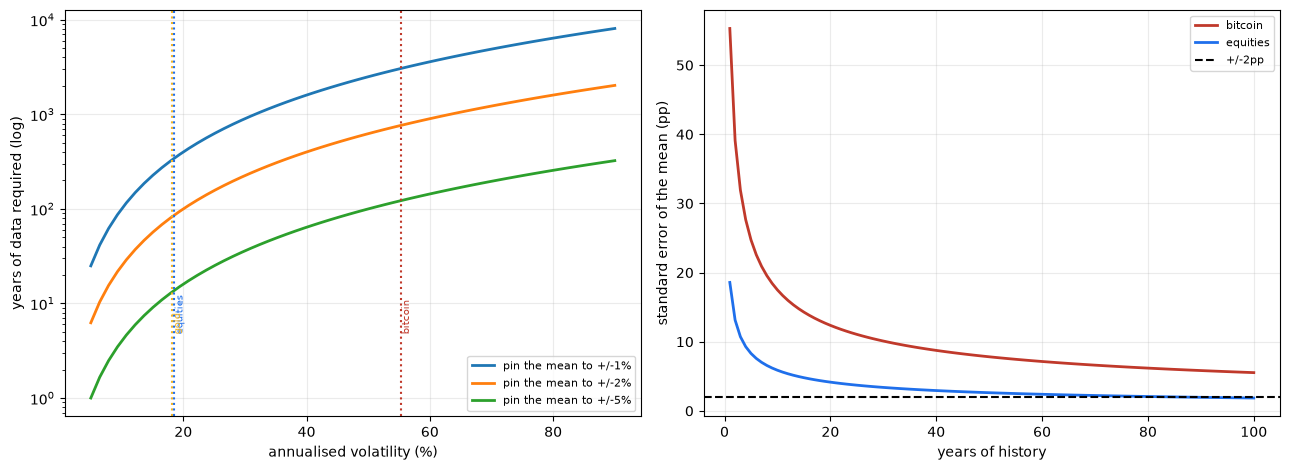

In [10]:
vols = np.linspace(0.05, 0.90, 60)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for target in (0.01, 0.02, 0.05):
    axes[0].plot(vols * 100, [(v / target) ** 2 for v in vols],
                 lw=2, label=f"pin the mean to +/-{target:.0%}")
axes[0].set_yscale("log"); axes[0].set_xlabel("annualised volatility (%)")
axes[0].set_ylabel("years of data required (log)"); axes[0].legend(fontsize=8)
for tk, label, col in ((data.BTC, "bitcoin", "#c0392b"),
                       (data.EQUITY, "equities", "#1f6feb"),
                       (data.GOLD, "gold", "#f0b429")):
    s = px[tk].dropna().pct_change().dropna()
    v = s.std(ddof=1) * np.sqrt(252)
    axes[0].axvline(v * 100, color=col, ls=":", lw=1.5)
    axes[0].annotate(label, (v * 100, 5), rotation=90, fontsize=7, color=col)
yrs = np.arange(1, 101)
for tk, label, col in ((data.BTC, "bitcoin", "#c0392b"),
                       (data.EQUITY, "equities", "#1f6feb")):
    s = px[tk].dropna().pct_change().dropna()
    v = s.std(ddof=1) * np.sqrt(252)
    axes[1].plot(yrs, v / np.sqrt(yrs) * 100, lw=2, color=col, label=label)
axes[1].axhline(2, color="k", ls="--", lw=1.5, label="+/-2pp")
axes[1].set_xlabel("years of history")
axes[1].set_ylabel("standard error of the mean (pp)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### 3.6 Out of sample, with costs

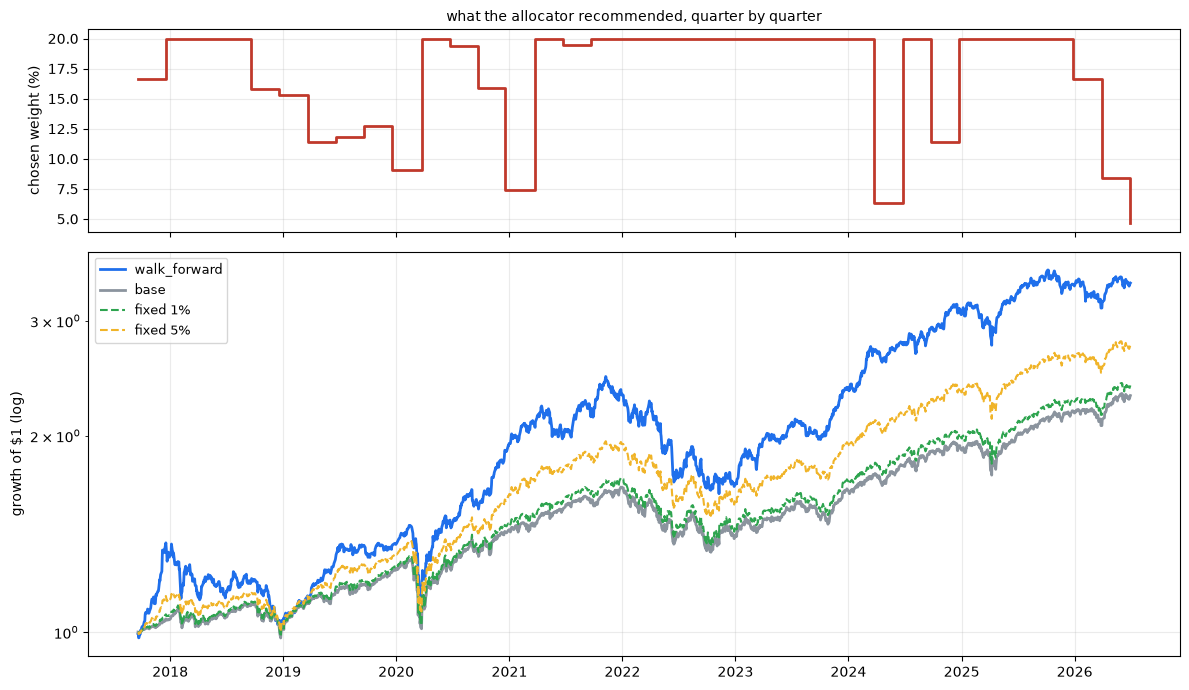

              walk_forward       base
cagr                0.1511     0.1000
vol                 0.1684     0.1188
sharpe              0.8973     0.8422
max_drawdown       -0.3386    -0.2172
sortino             1.1542     1.0281
calmar              0.4462     0.4607
skew               -0.5648    -0.3853
kurtosis            8.6691    14.6847
n               2,206.0000 2,206.0000


In [11]:
wf = st.walk_forward_weights(base, btc, 3.0, 63, 0.20, 30.0)
ws = st.walk_forward_series(base, btc, 3.0, 63, 0.20, 30.0)
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={"height_ratios": [1, 2]})
axes[0].step(wf.index, wf["weight"] * 100, where="post", lw=2, color="#c0392b")
axes[0].set_ylabel("chosen weight (%)")
axes[0].set_title("what the allocator recommended, quarter by quarter", fontsize=10)
for name, col in (("walk_forward", "#1f6feb"), ("base", "#8b949e")):
    axes[1].plot(ws.index, (1 + ws[name]).cumprod(), lw=2, color=col, label=name)
for w, col in ((0.01, "#2ea44f"), (0.05, "#f0b429")):
    fx = st.sleeve(ws["base"], btc.reindex(ws.index), w)
    axes[1].plot(fx.index, (1 + fx).cumprod(), lw=1.5, ls="--", color=col,
                 label=f"fixed {w:.0%}")
axes[1].set_yscale("log"); axes[1].set_ylabel("growth of $1 (log)")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
print(pd.DataFrame({n: st.stats(ws[n]) for n in ("walk_forward", "base")}).round(4)
      .to_string())

> \U0001F4A1 **In plain words.** The top panel is the point. An allocator whose recommendation
> swings across the whole admissible range every few quarters is not learning; it is resampling
> noise, exactly as §3.3 predicts it must.

### 3.7 The control — a known truth

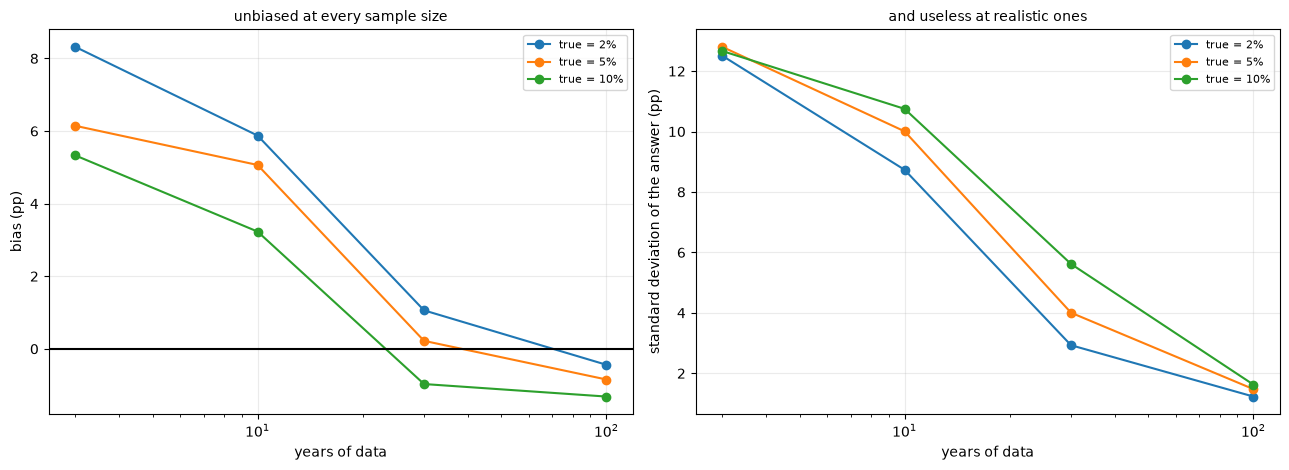

  true  years   mean     sd    bias
0.0200      3 0.1032 0.1251  0.0832
0.0200     10 0.0788 0.0873  0.0588
0.0200     30 0.0306 0.0293  0.0106
0.0200    100 0.0156 0.0123 -0.0044
0.0500      3 0.1114 0.1280  0.0614
0.0500     10 0.1006 0.1001  0.0506
0.0500     30 0.0522 0.0400  0.0022
0.0500    100 0.0415 0.0148 -0.0085
0.1000      3 0.1533 0.1267  0.0533
0.1000     10 0.1323 0.1075  0.0323
0.1000     30 0.0903 0.0562 -0.0097
0.1000    100 0.0868 0.0162 -0.0132


In [12]:
rows = []
for true_w in (0.02, 0.05, 0.10):
    for years in (3, 10, 30, 100):
        found = [st.optimal_weight(w["base"], w["asset"], 0.30) for w in
                 (st.synthetic_pair(n=int(years * 252), true_weight=true_w,
                                    seed=1003 + k) for k in range(10))]
        rows.append({"true": true_w, "years": years, "mean": np.mean(found),
                     "sd": np.std(found), "bias": np.mean(found) - true_w})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for tw, g in d.groupby("true"):
    axes[0].plot(g["years"], g["bias"] * 100, "o-", label=f"true = {tw:.0%}")
    axes[1].plot(g["years"], g["sd"] * 100, "o-", label=f"true = {tw:.0%}")
axes[0].axhline(0, color="k", lw=1.5)
axes[0].set_xscale("log"); axes[0].set_xlabel("years of data")
axes[0].set_ylabel("bias (pp)"); axes[0].legend(fontsize=8)
axes[0].set_title("unbiased at every sample size", fontsize=10)
axes[1].set_xscale("log"); axes[1].set_xlabel("years of data")
axes[1].set_ylabel("standard deviation of the answer (pp)"); axes[1].legend(fontsize=8)
axes[1].set_title("and useless at realistic ones", fontsize=10)
plt.tight_layout(); plt.show()
print(d.round(4).to_string(index=False))

### 3.8 Rebalancing, which decides what you own

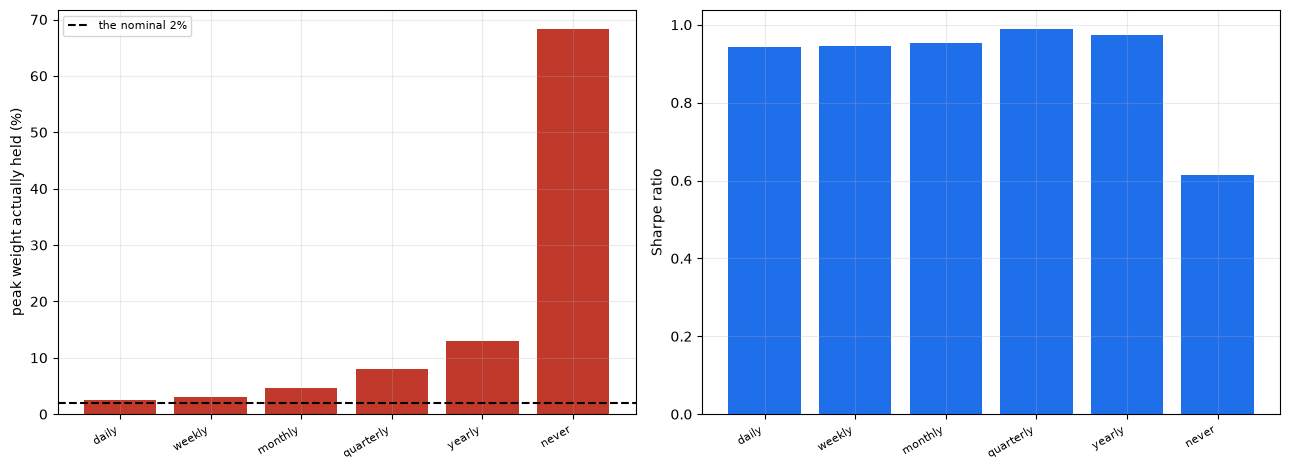

,max_weight_reached,cagr,vol,sharpe,max_drawdown
rebalance_days,,,,,
1,0.0249,0.1046,0.1110,0.9423,-0.2183
5,0.0304,0.1049,0.1110,0.9452,-0.2178
21,0.0467,0.1058,0.1110,0.9529,-0.2194
63,0.0799,0.1101,0.1114,0.9885,-0.2202
252,0.1292,0.1109,0.1138,0.9743,-0.2192
10000,0.6827,0.1533,0.2492,0.6152,-0.5263


In [13]:
rb = st.rebalancing_matters(base, btc, 0.02, (1, 5, 21, 63, 252, 10_000))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
lbl = ["daily", "weekly", "monthly", "quarterly", "yearly", "never"]
axes[0].bar(lbl, rb["max_weight_reached"] * 100, color="#c0392b")
axes[0].axhline(2, color="k", ls="--", lw=1.5, label="the nominal 2%")
axes[0].set_ylabel("peak weight actually held (%)"); axes[0].legend(fontsize=8)
axes[1].bar(lbl, rb["sharpe"], color="#1f6feb")
axes[1].set_ylabel("Sharpe ratio")
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
plt.tight_layout(); plt.show()
rb[["max_weight_reached", "cagr", "vol", "sharpe", "max_drawdown"]].round(4)

### 3.9 Is bitcoin special, or is this every volatile diversifier?

           corr    vol   best  plateau  boot_sd  boot_span
asset                                                     
BTC-USD  0.2326 0.6611 0.1650   0.0900   0.1178     0.4500
GLD      0.1203 0.1611 0.3000   0.0375   0.1191     0.3755
TLT     -0.0143 0.1479 0.0975   0.1575   0.1144     0.3205


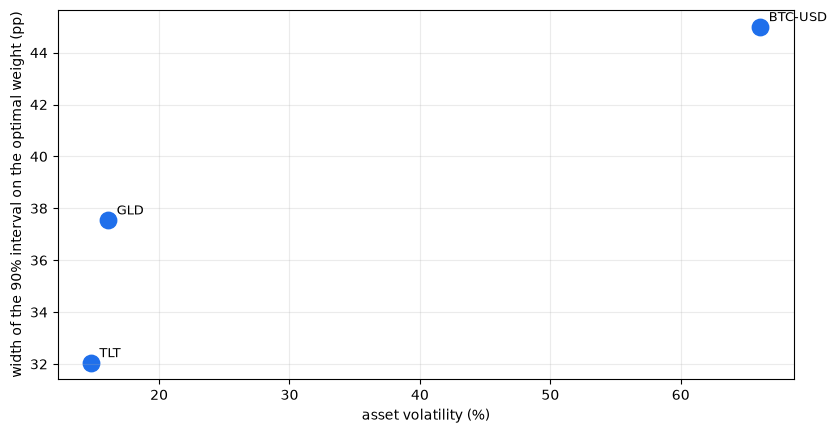

In [14]:
rows = []
for tk in (data.BTC, data.GOLD, data.LONG_BONDS):
    a = rets[tk].reindex(common).dropna()
    bb = base.reindex(a.index)
    cu = st.objective_curve(bb, a, 0.30, n=41)
    ff = st.flatness(cu, 0.01)
    bs = st.weight_standard_error(bb, a, 0.50, n_boot=150)
    rows.append({"asset": tk, "corr": bb.corr(a), "vol": a.std(ddof=1) * np.sqrt(252),
                 "best": ff["best_weight"], "plateau": ff["plateau_width"],
                 "boot_sd": bs["sd"], "boot_span": bs["p95"] - bs["p05"]})
d = pd.DataFrame(rows).set_index("asset")
print(d.round(4).to_string())
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.scatter(d["vol"] * 100, d["boot_span"] * 100, s=140, color="#1f6feb")
for tk, row in d.iterrows():
    ax.annotate(tk, (row["vol"] * 100, row["boot_span"] * 100), fontsize=9,
                xytext=(6, 4), textcoords="offset points")
ax.set_xlabel("asset volatility (%)")
ax.set_ylabel("width of the 90% interval on the optimal weight (pp)")
plt.show()

> \U0001F4A1 **In plain words.** Nothing here is about bitcoin specifically. It is about
> volatility, and bitcoin simply has the most of it.

## 4 · The verdict

In [15]:
curve = st.objective_curve(base, btc, 0.30, n=61)
f = st.flatness(curve, 0.01)
boot = st.weight_standard_error(base, btc, 0.50, n_boot=300)
p = st.power_to_distinguish(base, btc, 0.01, 0.05, n_boot=250)
vol = btc.std(ddof=1) * np.sqrt(252)
pd.DataFrame({
    "60/40 Sharpe alone": [st.stats(base)["sharpe"]],
    "Sharpe-maximising sleeve": [f["best_weight"]],
    "its Sharpe": [f["best_value"]],
    "weights within 1% of optimal": [f["plateau_width"]],
    "bootstrap 5th percentile": [boot["p05"]],
    "bootstrap 95th percentile": [boot["p95"]],
    "draws landing at zero": [boot["share_at_zero"]],
    "5% beats 1% in this share of draws": [p["share_b_wins"]],
    "1% vs 5% distinguishable": [float(p["distinguishable"])],
    "bitcoin's realised return": [np.expm1(np.log1p(btc).sum() * 252 / len(btc))],
    "expected return a 1% sleeve implies": [
        st.implied_mean_for_weight(base, btc, (0.01,))["implied_mean"].iloc[0]],
    "expected return a 2% sleeve implies": [
        st.implied_mean_for_weight(base, btc, (0.02,))["implied_mean"].iloc[0]],
    "bitcoin volatility (252d)": [vol],
    "years to pin its mean to +/-2pp": [st.sample_needed(0, vol, 0.02)["years_needed"]],
    "standard error on the mean today": [vol / np.sqrt(len(btc) / 252)],
}).T.rename(columns={0: "value"}).round(4)

,value
60/40 Sharpe alone,0.8515
Sharpe-maximising sleeve,0.1650
its Sharpe,1.1841
weights within 1% of optimal,0.0900
bootstrap 5th percentile,0.0599
bootstrap 95th percentile,0.5000
draws landing at zero,0.0000
5% beats 1% in this share of draws,0.9920
1% vs 5% distinguishable,1.0000
bitcoin's realised return,0.5111


## 5 · Going further

- **Bayesian shrinkage** (Black-Litterman, or a simple prior of zero excess return) is the
  standard response to §3.3, and it works by making the answer depend on the prior rather than
  the data — which is honest, and worth stating plainly rather than presenting as an
  improvement in estimation.
- **Resampled efficiency** (Michaud) averages the optimiser over bootstrap draws. On the numbers
  in §3.3 that average would land near the middle of a nearly uniform distribution, which is a
  reasonable default and not a discovery.
- **Utility other than Sharpe.** Bitcoin's contribution to the left tail exceeds its
  contribution to variance, so a CRRA or drawdown-constrained investor gets a smaller answer.
  Repeating §3.1 under a power utility would be a clean extension.
- **The estimability frame generalises.** Any allocation recommendation for a high-volatility
  asset can be checked against §3.5 before its backtest is read, and most will not survive it.